# ResNet-152 (No Pretraining) for Dead Tree Segmentation

Binary semantic segmentation using a ResNet-152 backbone initialised with **random weights** (no ImageNet pretraining). This serves as a baseline to compare against the pretrained ResNet-152 and DINOv2 variants.

Architecture: ResNet-152 feature extractor (fc and avgpool removed) → 1×1 conv → bilinear upsample ×32 to input resolution.

Dataset: [saking3/alaska_dead_trees](https://huggingface.co/datasets/saking3/alaska_dead_trees)

## Configuration

Update the paths below before running.

In [ ]:
# --- Paths (update before running) ---
MODEL_CHECKPOINT_PATH = '/explore/nobackup/people/sking11/RAWresnet152_model_checkpoint_10.pth'
MODEL_FULL_PATH        = '/explore/nobackup/people/sking11/RAWresnet152_model_10.pth'
INFERENCE_MODEL_PATH   = '/explore/nobackup/people/sking11/RAWresnet152_model_10.pth'
PREDICTION_MASK_PATH   = '/explore/nobackup/people/sking11/saved_figures/predictedmaskRAWresnet152_10.png'
ACCURACIES_CSV_PATH    = '/explore/nobackup/people/sking11/accuracies/RAWresnet152_10_accuracies.csv'

# --- Training hyperparameters ---
NUM_EPOCHS    = 30
LEARNING_RATE = 1e-4
BATCH_SIZE    = 2
TRAINING_SIZE = 10  # set to None to use the full training set

## 1. Imports

In [ ]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader
from PIL import Image
from tqdm import tqdm
from datasets import load_dataset, DatasetDict
from sklearn.metrics import confusion_matrix

## 2. Load Data

Set `TRAINING_SIZE` in the config block above to subsample the training set, or `None` to use all 6400 training images.

In [ ]:
dataset = load_dataset('saking3/alaska_dead_trees')

if TRAINING_SIZE is not None:
    random_indices = np.random.choice(len(dataset['train']), size=TRAINING_SIZE, replace=False)
    dataset = DatasetDict({
        'train':      dataset['train'].select(random_indices),
        'validation': dataset['validation'],
        'test':       dataset['test']
    })

id2label = {0: 'Background', 1: 'Dead Tree'}

## 3. Dataset and Transforms

Images are resized to 448×448 and normalised with ImageNet channel statistics. Masks are returned as float tensors with a channel dimension added.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class ForestDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset   = dataset
        self.transform = transform

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image  = sample['image']
        mask   = sample['label']
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image)
        if self.transform:
            image = self.transform(image)
        mask = torch.tensor(np.array(mask), dtype=torch.float).unsqueeze(0)
        return image, mask

    def __len__(self):
        return len(self.dataset)

In [ ]:
train_dataset = ForestDataset(dataset['train'],      transform=train_transform)
val_dataset   = ForestDataset(dataset['validation'], transform=val_transform)
test_dataset  = ForestDataset(dataset['test'],       transform=val_transform)

print('Number of train images:', len(train_dataset))
print('Number of val images:',   len(val_dataset))
print('Number of test images:',  len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1,          shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

Number of train images: 10
Number of val images: 653
Number of test images: 1286


## 4. Model Architecture

`ResNetSegmentationModel` uses the ResNet-152 convolutional backbone (fc and avgpool removed) with no pretrained weights. A 1×1 conv maps the 2048-channel feature map to a single binary output channel, which is then bilinearly upsampled ×32 back to input resolution.

In [ ]:
class ResNetSegmentationModel(nn.Module):
    def __init__(self, num_classes=1):
        super().__init__()
        # ResNet-152 with random initialisation (no ImageNet weights)
        backbone   = models.resnet152(weights=None)
        self.resnet = nn.Sequential(*list(backbone.children())[:-2])
        self.conv   = nn.Conv2d(2048, num_classes, kernel_size=1)

    def forward(self, x):
        x = self.resnet(x)  # [B, 2048, H/32, W/32]
        x = self.conv(x)    # [B, num_classes, H/32, W/32]
        x = nn.functional.interpolate(x, scale_factor=32, mode='bilinear', align_corners=True)
        return x

## 5. Training

In [ ]:
device    = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model     = ResNetSegmentationModel(num_classes=1).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    with tqdm(train_loader, unit='batch') as tepoch:
        for images, masks in tepoch:
            images, masks = images.to(device), masks.to(device)
            outputs    = model(images)
            loss       = criterion(outputs, masks)
            epoch_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            tepoch.set_description(f'Epoch {epoch+1}/{NUM_EPOCHS}')
            tepoch.set_postfix(loss=loss.item())
    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Average Loss: {epoch_loss / len(train_loader):.4f}')

In [ ]:
torch.save(model.state_dict(), MODEL_CHECKPOINT_PATH)
torch.save(model, MODEL_FULL_PATH)

## 6. Inference

### 6a. Single-image prediction

In [ ]:
model = torch.load(INFERENCE_MODEL_PATH, weights_only=False)
model.eval()
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)

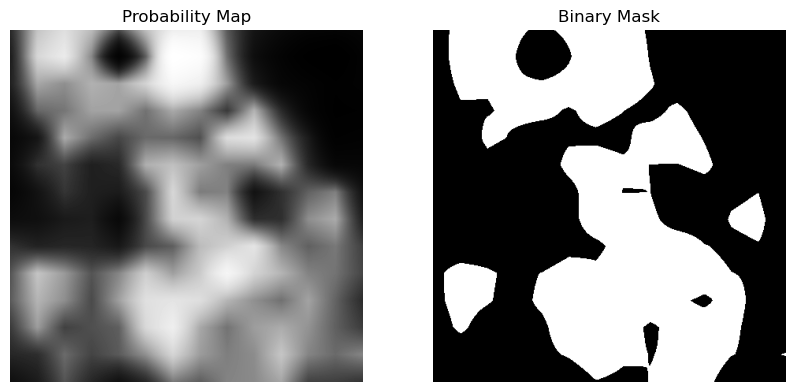

In [ ]:
val_image, _ = val_dataset[300]  # change index as needed
pixel_values = val_image.clone().detach().unsqueeze(0)

model.eval()
with torch.no_grad():
    outputs = model(pixel_values.to(device))

predicted_probabilities = torch.sigmoid(outputs).squeeze().cpu().numpy()
predicted_binary_mask   = (predicted_probabilities > 0.5).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(predicted_probabilities, cmap='gray')
axes[0].set_title('Probability Map')
axes[0].axis('off')
axes[1].imshow(predicted_binary_mask, cmap='gray')
axes[1].set_title('Binary Mask')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
binary_mask_image = Image.fromarray(predicted_binary_mask * 255)
binary_mask_image.save(PREDICTION_MASK_PATH)

### 6b. Batch inference over validation set

In [ ]:
model.eval()
predicted_arrays = []

with torch.no_grad():
    for images, _ in tqdm(val_loader, desc='Running predictions'):
        images  = images.to(device)
        outputs = model(images)
        for j in range(outputs.size(0)):
            pred = outputs[j].squeeze(0)
            # Resize to match ground-truth mask resolution (256x256)
            pred_resized = F.interpolate(
                pred.unsqueeze(0).unsqueeze(0), size=(256, 256),
                mode='bilinear', align_corners=True
            ).squeeze().cpu().numpy()
            predicted_arrays.append((pred_resized > 0.5).astype(np.uint8))

Running predictions: 100%|██████████| 653/653 [00:16<00:00, 40.30it/s]


In [ ]:
val_masks_list = []
for idx in tqdm(range(len(val_dataset)), desc='Processing validation masks'):
    _, mask = val_dataset[idx]
    mask_np = mask.squeeze(0).cpu().numpy()
    val_masks_list.append((mask_np > 0.5).astype(np.uint8))

Processing validation masks: 100%|██████████| 653/653 [00:07<00:00, 89.32it/s] 


## 7. Evaluation

In [ ]:
total_correct = sum(
    np.sum(p.flatten() == a.flatten())
    for p, a in zip(predicted_arrays, val_masks_list)
)
total_pixels = sum(a.size for a in val_masks_list)
print(f'Total Accuracy: {total_correct / total_pixels:.4f}')

Total Accuracy: 0.9713771054792185


In [ ]:
def calculate_iou(predicted_mask, actual_mask):
    predicted_mask = (predicted_mask > 0.5).astype(np.uint8)
    actual_mask    = (actual_mask > 0.5).astype(np.uint8)
    intersection   = np.logical_and(predicted_mask, actual_mask)
    union          = np.logical_or(predicted_mask, actual_mask)
    return np.sum(intersection) / np.sum(union)

mean_iou = np.mean([calculate_iou(p, a) for p, a in zip(predicted_arrays, val_masks_list)])
print(f'Mean IoU: {mean_iou:.4f}')

Mean IoU: 0.1406


In [ ]:
actual_flat    = np.concatenate([m.flatten() for m in val_masks_list])
predicted_flat = np.concatenate([m.flatten() for m in predicted_arrays])
conf_matrix    = confusion_matrix(actual_flat, predicted_flat, labels=[0, 1])
print('Confusion Matrix:')
print(conf_matrix)

Confusion Matrix:
[[27868113 12014554]
 [  636672  2275669]]


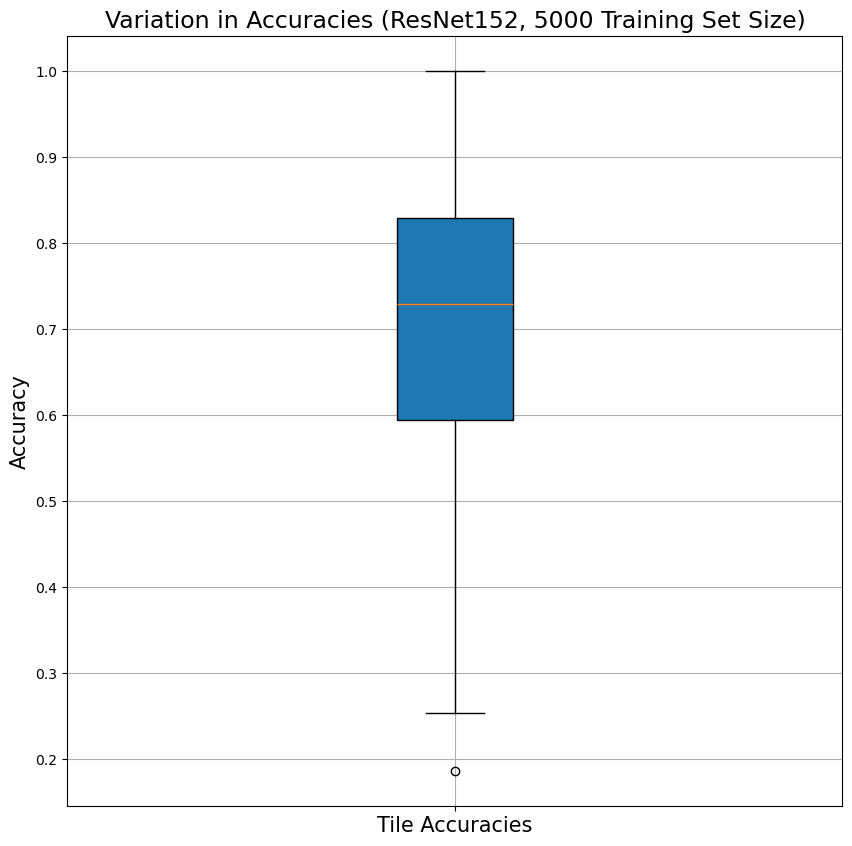

In [ ]:
tile_accs = [
    np.sum(a == p) / a.size
    for a, p in zip(val_masks_list, predicted_arrays)
]
print(f'Mean tile accuracy: {np.mean(tile_accs):.4f}  |  Std: {np.std(tile_accs):.4f}  |  Min: {np.min(tile_accs):.4f}')

plt.figure(figsize=(8, 5))
plt.boxplot(tile_accs, vert=True, patch_artist=True)
plt.title('Distribution of Per-Tile Accuracies (RAW ResNet-152)')
plt.ylabel('Accuracy')
plt.xticks([1], ['Validation Tiles'])
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
with open(ACCURACIES_CSV_PATH, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['Tile', 'Accuracy'])
    for idx, acc in enumerate(tile_accs):
        writer.writerow([idx, acc])